In [41]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import re
from collections import Counter
from IPython.display import display

In [2]:
df = pd.read_excel("../Prueba 2/Base sintetica conversaciones.xlsx")

# 1.Estructura del Dataset

In [3]:
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print(f'Memoria:  {df.memory_usage(deep=True).sum()/1024**2:.1f} MB')
df.head()

Filas:    42,607
Columnas: 8
Memoria:  8.4 MB


,uk_id_conversacion,total_interacciones,anio,mes,de,uk_id_mensaje,uk_id_conversacion1,mensaje
0,CONV_00000001,37,2010,Julio,USUARIO,MSG_00000001,CONV_00000001,HABLAR CON ASESOR
1,CONV_00000001,37,2010,Julio,BOT,MSG_00000002,CONV_00000001,AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEA...
2,CONV_00000001,37,2010,Julio,BOT,MSG_00000003,CONV_00000001,ESTAMOS VALIDANDO TU INFORMACIÓN. EN UN MOMENT...
3,CONV_00000001,37,2010,Julio,BOT,MSG_00000004,CONV_00000001,"HOLA, MI NOMBRE ES PERSONA_00000134, SOY ASESO..."
4,CONV_00000001,37,2010,Julio,USUARIO,MSG_00000005,CONV_00000001,FECHA_ANONIMIZADA


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42607 entries, 0 to 42606
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   uk_id_conversacion   42607 non-null  str  
 1   total_interacciones  42607 non-null  int64
 2   anio                 42607 non-null  int64
 3   mes                  42607 non-null  str  
 4   de                   42607 non-null  str  
 5   uk_id_mensaje        42607 non-null  str  
 6   uk_id_conversacion1  42607 non-null  str  
 7   mensaje              42606 non-null  str  
dtypes: int64(2), str(6)
memory usage: 8.4 MB


## Perfil De Variables

In [ ]:
def perfil_columnas(df):
    filas = []
    for c in df.columns:
        s = df[c]
        filas.append({
            'columna': c,
            'dtype': str(s.dtype),
            'no_nulos': s.notna().sum(),
            'nulos': s.isna().sum(),
            '%_nulos': round(s.isna().mean()*100, 2),
            'unicos': s.nunique(dropna=True),
            '%_unicos': round(s.nunique(dropna=True)/len(s)*100, 2),
            'ejemplo': str(s.dropna().iloc[0])[:55] if s.notna().any() else None,
        })
    return pd.DataFrame(filas).set_index('columna')

perfil = perfil_columnas(df)
perfil

,dtype,no_nulos,nulos,%_nulos,unicos,%_unicos,ejemplo
columna,,,,,,,
uk_id_conversacion,str,42607,0,0.0,1197,2.81,CONV_00000001
total_interacciones,int64,42607,0,0.0,79,0.19,37
anio,int64,42607,0,0.0,1,0.00,2010
mes,str,42607,0,0.0,1,0.00,Julio
de,str,42607,0,0.0,4,0.01,USUARIO
uk_id_mensaje,str,42607,0,0.0,42005,98.59,MSG_00000001
uk_id_conversacion1,str,42607,0,0.0,1197,2.81,CONV_00000001
mensaje,str,42606,1,0.0,21168,49.68,HABLAR CON ASESOR


# 2. Calidad de Datos

## 2.1 Valores Faltantes

In [6]:
faltantes = pd.DataFrame({
    'nulos': df.isna().sum(),
    '%_nulos': (df.isna().mean()*100).round(3)
}).sort_values('nulos', ascending=False)

print(f'Total de celdas nulas: {df.isna().sum().sum()}')
print(f'Filas con al menos un nulo: {df.isna().any(axis=1).sum()}')
faltantes

Total de celdas nulas: 1
Filas con al menos un nulo: 1


,nulos,%_nulos
mensaje,1,0.002
uk_id_conversacion,0,0.000
anio,0,0.000
total_interacciones,0,0.000
mes,0,0.000
de,0,0.000
uk_id_mensaje,0,0.000
uk_id_conversacion1,0,0.000


In [7]:
# Inspección de la fila con mensaje nulo
df[df.mensaje.isna()]

,uk_id_conversacion,total_interacciones,anio,mes,de,uk_id_mensaje,uk_id_conversacion1,mensaje
30415,CONV_00000852,37,2010,Julio,USUARIO,MSG_00029885,CONV_00000852,NaN


## 2.2 Duplicados

Se validan tres niveles de duplicidad: registros completamente idénticos, mensajes con el mismo identificador y mensajes con contenido repetido, algo que en este contexto es normal

In [8]:
#Duplicados
dup_completas = df.duplicated().sum()
dup_id_msg    = df.uk_id_mensaje.duplicated().sum()
dup_contenido = df.mensaje.duplicated().sum()

print(f'Filas completamente duplicadas:      {dup_completas:>6,}  ({dup_completas/len(df)*100:.2f}%)')
print(f'uk_id_mensaje repetido:              {dup_id_msg:>6,}  ({dup_id_msg/len(df)*100:.2f}%)')
print(f'Contenido de mensaje repetido:       {dup_contenido:>6,}  ({dup_contenido/len(df)*100:.2f}%)')
print()
print('Los dos primeros son un problema de calidad; el tercero es esperable (plantillas de bot).')

Filas completamente duplicadas:         602  (1.41%)
uk_id_mensaje repetido:                 602  (1.41%)
Contenido de mensaje repetido:       21,438  (50.32%)

Los dos primeros son un problema de calidad; el tercero es esperable (plantillas de bot).


In [9]:
# ¿Los ids repetidos corresponden a filas idénticas o a colisiones reales?
ids_rep = df[df.uk_id_mensaje.duplicated(keep=False)]
print(f'Filas involucradas en ids repetidos: {len(ids_rep)}')
print(f'De ellas, filas idénticas en todo:   {ids_rep.duplicated(keep=False).sum()}')
print()
ids_rep.sort_values('uk_id_mensaje').head(4)

Filas involucradas en ids repetidos: 955
De ellas, filas idénticas en todo:   955



,uk_id_conversacion,total_interacciones,anio,mes,de,uk_id_mensaje,uk_id_conversacion1,mensaje
946,CONV_00000027,28,2010,Julio,HSM,MSG_00000947,CONV_00000027,BANCO_000001 :BLUE_HEART: ¡HOLA!\NHEMOS INTENT...
947,CONV_00000027,28,2010,Julio,HSM,MSG_00000947,CONV_00000027,BANCO_000001 :BLUE_HEART: ¡HOLA!\NHEMOS INTENT...
948,CONV_00000027,28,2010,Julio,USUARIO,MSG_00000948,CONV_00000027,ME INTERESA
949,CONV_00000027,28,2010,Julio,USUARIO,MSG_00000948,CONV_00000027,ME INTERESA


## 2.3 Consistencia de Llaves

**uk_id_conversacion1** parece una copia de **uk_id_conversacion**. Se verifica antes de descartarla.
También se comprueba si **total_interacciones** es coherente con el conteo real de mensajes.

In [10]:
print('uk_id_conversacion1 == uk_id_conversacion en todas las filas:',
      (df.uk_id_conversacion == df.uk_id_conversacion1).all())

# ¿total_interacciones es constante dentro de cada conversación?
chk = df.groupby('uk_id_conversacion').agg(
    n_real=('uk_id_mensaje', 'size'),
    n_declarado=('total_interacciones', 'first'),
    valores_distintos=('total_interacciones', 'nunique'),
)
print('total_interacciones constante dentro de cada conversación:',
      (chk.valores_distintos == 1).all())
print(f'Coincide con el conteo real en el {(chk.n_real == chk.n_declarado).mean()*100:.1f}% de las conversaciones')

chk['diferencia'] = chk.n_real - chk.n_declarado
chk[chk.diferencia != 0].head(10)

uk_id_conversacion1 == uk_id_conversacion en todas las filas: True
total_interacciones constante dentro de cada conversación: True
Coincide con el conteo real en el 99.2% de las conversaciones


,n_real,n_declarado,valores_distintos,diferencia
uk_id_conversacion,,,,
CONV_00000027,56,28,1,28
CONV_00000234,106,53,1,53
CONV_00000319,88,22,1,66
CONV_00000380,228,57,1,171
CONV_00000492,50,25,1,25
CONV_00000580,120,60,1,60
CONV_00000604,58,29,1,29
CONV_00000795,132,33,1,99
CONV_00001134,75,25,1,50


## 2.4 Cardinalidad de las Variables

Una columna con un solo valor no aporta información y debe descartarse del análisis.

In [11]:
cardinalidad = df.nunique().sort_values()
constantes = cardinalidad[cardinalidad == 1]

print('Cardinalidad por columna:')
print(cardinalidad.to_string())
print()
print('Columnas constantes (sin poder discriminante):', list(constantes.index) if len(constantes) else 'ninguna')

for c in ['anio', 'mes']:
    print(f'\n{c}: {df[c].unique()}')

Cardinalidad por columna:
mes                        1
anio                       1
de                         4
total_interacciones       79
uk_id_conversacion      1197
uk_id_conversacion1     1197
mensaje                21168
uk_id_mensaje          42005

Columnas constantes (sin poder discriminante): ['mes', 'anio']

anio: [2010]

mes: <ArrowStringArray>
['Julio']
Length: 1, dtype: str


# 3. Analisis Univariado

## 3.1 Variables Categoricas

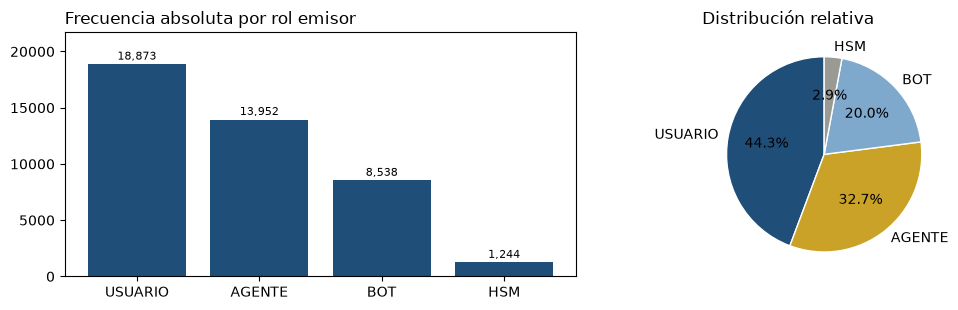

In [13]:
def resumen_categorica(s, nombre):
    t = pd.DataFrame({
        'frecuencia': s.value_counts(),
        '%': (s.value_counts(normalize=True)*100).round(2),
    })
    t.index.name = nombre
    return t

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))

vc = df['de'].value_counts()
ax[0].bar(vc.index, vc.values, color='#1f4e79')
for i, v in enumerate(vc.values):
    ax[0].text(i, v + 400, f'{v:,}', ha='center', fontsize=8)
ax[0].set_title('Frecuencia absoluta por rol emisor', loc='left')
ax[0].set_ylim(0, vc.max()*1.15)

ax[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', startangle=90,
          colors=['#1f4e79', '#c9a227', '#7fa8cd', '#9a9a95'],
          wedgeprops={'edgecolor': 'white', 'linewidth': 1})
ax[1].set_title('Distribución relativa', loc='left')

plt.tight_layout()
plt.show()

## 3.2 Variables Numericas
La única numérica original es **total_interacciones**

In [14]:
def resumen_numerica(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    return pd.Series({
        'n': s.notna().sum(),
        'nulos': s.isna().sum(),
        'media': s.mean(),
        'mediana': s.median(),
        'moda': s.mode().iloc[0] if not s.mode().empty else np.nan,
        'desv_est': s.std(),
        'coef_variacion': s.std()/s.mean() if s.mean() else np.nan,
        'min': s.min(),
        'p05': s.quantile(0.05), 'q1': q1, 'q3': q3, 'p95': s.quantile(0.95),
        'max': s.max(),
        'rango_iqr': iqr,
        'asimetria': s.skew(),
        'curtosis': s.kurtosis(),
        'lim_inf_iqr': lim_inf,
        'lim_sup_iqr': lim_sup,
        'n_outliers': ((s < lim_inf) | (s > lim_sup)).sum(),
        '%_outliers': round(((s < lim_inf) | (s > lim_sup)).mean()*100, 2),
    })

resumen_numerica(df.total_interacciones).round(2)

n                 42607.00
nulos                 0.00
media                43.51
mediana              36.00
moda                 24.00
desv_est             23.75
coef_variacion        0.55
min                  20.00
p05                  21.00
q1                   26.00
q3                   54.00
p95                  86.00
max                 160.00
rango_iqr            28.00
asimetria             1.83
curtosis              4.28
lim_inf_iqr         -16.00
lim_sup_iqr          96.00
n_outliers         1649.00
%_outliers            3.87
dtype: float64

C:\Users\andre\AppData\Local\Temp\ipykernel_3524\3877669716.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(s, vert=False, widths=0.6,


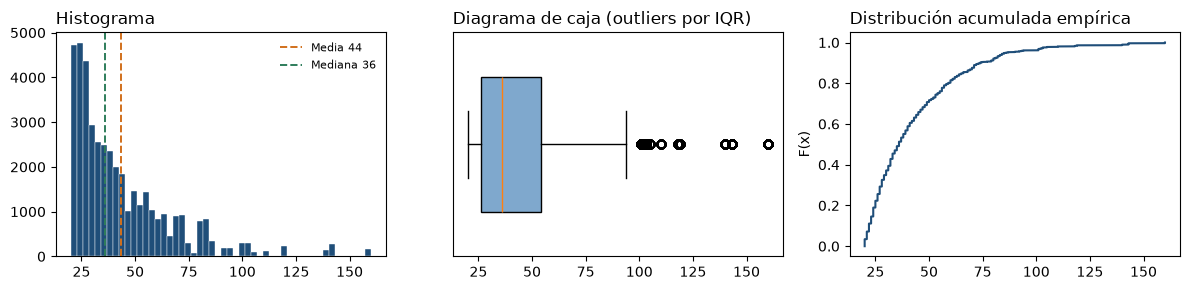

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
s = df.total_interacciones

ax[0].hist(s, bins=50, color='#1f4e79', edgecolor='white', linewidth=0.3)
ax[0].axvline(s.mean(), color='#d1701c', ls='--', lw=1.4, label=f'Media {s.mean():.0f}')
ax[0].axvline(s.median(), color='#2e7d5b', ls='--', lw=1.4, label=f'Mediana {s.median():.0f}')
ax[0].set_title('Histograma', loc='left'); ax[0].legend(frameon=False, fontsize=8)

ax[1].boxplot(s, vert=False, widths=0.6,
              patch_artist=True, boxprops={'facecolor': '#7fa8cd'})
ax[1].set_title('Diagrama de caja (outliers por IQR)', loc='left'); ax[1].set_yticks([])

xs = np.sort(s); ax[2].plot(xs, np.arange(1, len(xs)+1)/len(xs), color='#1f4e79')
ax[2].set_title('Distribución acumulada empírica', loc='left'); ax[2].set_ylabel('F(x)')

plt.tight_layout(); plt.show()

## 3.3 Variable de Texto

**mensaje** es la variable principal. Se perfila su longitud en caracteres y palabras, y se
cuantifican los casos degenerados (vacíos, extremadamente cortos o largos).

In [16]:
df['msg'] = (df.mensaje.fillna('')
                       .astype(str)
                       .str.replace(r'\\N', ' ', regex=True)   # salto de línea escapado
                       .str.strip())

df['n_caracteres'] = df.msg.str.len()
df['n_palabras']   = df.msg.str.split().str.len().fillna(0).astype(int)

print('LONGITUD EN CARACTERES'); print(resumen_numerica(df.n_caracteres).round(2).to_string())
print(); print('LONGITUD EN PALABRAS'); print(resumen_numerica(df.n_palabras).round(2).to_string())

LONGITUD EN CARACTERES
n                 42607.00
nulos                 0.00
media                93.19
mediana              59.00
moda                 14.00
desv_est            102.76
coef_variacion        1.10
min                   0.00
p05                   4.00
q1                   22.00
q3                  152.00
p95                 269.00
max                1151.00
rango_iqr           130.00
asimetria             2.80
curtosis             13.84
lim_inf_iqr        -173.00
lim_sup_iqr         347.00
n_outliers         1160.00
%_outliers            2.72

LONGITUD EN PALABRAS
n                 42607.00
nulos                 0.00
media                15.18
mediana              10.00
moda                  1.00
desv_est             16.23
coef_variacion        1.07
min                   0.00
p05                   1.00
q1                    3.00
q3                   24.00
p95                  41.00
max                 256.00
rango_iqr            21.00
asimetria             2.87
curtosis  

In [17]:
casos = pd.Series({
    'mensajes vacíos':                (df.n_caracteres == 0).sum(),
    'de 1 sola palabra':              (df.n_palabras == 1).sum(),
    'de 2 palabras o menos':          (df.n_palabras <= 2).sum(),
    'de más de 100 palabras':         (df.n_palabras > 100).sum(),
    'solo dígitos':                   df.msg.str.fullmatch(r'\d+').sum(),
    'solo signos de puntuación':      df.msg.str.fullmatch(r'[^\w\s]+').sum(),
    'contienen marcador anonimizado': df.msg.str.contains(r'[A-Z]+_\d{6,}|ANONIMIZAD').sum(),
    'contienen URL anonimizada':      df.msg.str.contains('URL_ANONIMIZADA').sum(),
})
pd.DataFrame({'n': casos, '%': (casos/len(df)*100).round(2)})

,n,%
mensajes vacíos,1,0.00
de 1 sola palabra,5736,13.46
de 2 palabras o menos,8302,19.49
de más de 100 palabras,229,0.54
solo dígitos,716,1.68
solo signos de puntuación,106,0.25
contienen marcador anonimizado,13051,30.63
contienen URL anonimizada,1822,4.28


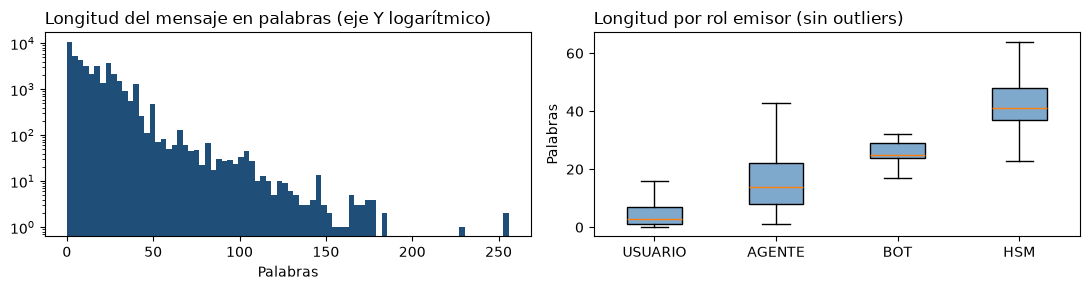

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3))

ax[0].hist(df.n_palabras, bins=80, color='#1f4e79')
ax[0].set_yscale('log')
ax[0].set_title('Longitud del mensaje en palabras (eje Y logarítmico)', loc='left')
ax[0].set_xlabel('Palabras')

datos = [df.loc[df.de == r, 'n_palabras'].values for r in df.de.value_counts().index]
bp = ax[1].boxplot(datos, tick_labels=df.de.value_counts().index, patch_artist=True, showfliers=False)
for caja in bp['boxes']:
    caja.set_facecolor('#7fa8cd')
ax[1].set_title('Longitud por rol emisor (sin outliers)', loc='left')
ax[1].set_ylabel('Palabras')

plt.tight_layout(); plt.show()

# 4. Agregación a nivel conversación

La unidad de análisis es la conversación, no el mensaje. Se construye una tabla consolidada por conversación y se generan las variables derivadas.

## 4.1 Limpieza Previa

Se aplican las decisiones definidas en la sección 2: eliminar duplicados exactos, remover la columna redundante y establecer el orden de los mensajes.

In [20]:
limpio = (df
    .drop_duplicates(subset=[c for c in df.columns if c not in ('msg','n_caracteres','n_palabras')])
    .drop(columns=['uk_id_conversacion1'])
    .copy())

# No hay timestamp: el consecutivo de uk_id_mensaje define el orden
limpio['orden'] = limpio.uk_id_mensaje.str.extract(r'(\d+)').astype(int)
limpio = limpio.sort_values(['uk_id_conversacion', 'orden']).reset_index(drop=True)

es_monotono = limpio.groupby('uk_id_conversacion').orden.apply(lambda s: s.is_monotonic_increasing).all()
print(f'Filas tras limpieza: {len(limpio):,}  (se eliminaron {len(df)-len(limpio):,})')
print(f'Orden monótono dentro de cada conversación: {es_monotono}')

Filas tras limpieza: 42,005  (se eliminaron 602)
Orden monótono dentro de cada conversación: True


**Agrupar mensajes en Conversaciones**

In [21]:
piv = (limpio.pivot_table(index='uk_id_conversacion', columns='de',
                          values='uk_id_mensaje', aggfunc='count')
             .fillna(0).astype(int))
piv.columns = [f'msgs_{c.lower()}' for c in piv.columns]

conv = (limpio.groupby('uk_id_conversacion')
              .agg(n_mensajes=('uk_id_mensaje', 'size'),
                   n_palabras=('n_palabras', 'sum'),
                   n_caracteres=('n_caracteres', 'sum'),
                   long_media_msg=('n_palabras', 'mean'))
              .join(piv))

for rol in ['usuario', 'agente', 'bot', 'hsm']:
    col = f'msgs_{rol}'
    if col in conv.columns:
        conv[f'pct_{rol}'] = (conv[col] / conv.n_mensajes * 100).round(1)

conv['ratio_agente_usuario'] = (conv.msgs_agente / conv.msgs_usuario.replace(0, np.nan)).round(2)

print(f'Conversaciones: {len(conv):,}')
conv.head()

Conversaciones: 1,197


,n_mensajes,n_palabras,n_caracteres,long_media_msg,msgs_agente,msgs_bot,msgs_hsm,msgs_usuario,pct_usuario,pct_agente,pct_bot,pct_hsm,ratio_agente_usuario
uk_id_conversacion,,,,,,,,,,,,,
CONV_00000001,37,517,3200,13.972973,9,12,1,15,40.5,24.3,32.4,2.7,0.60
CONV_00000002,38,467,2765,12.289474,9,9,1,19,50.0,23.7,23.7,2.6,0.47
CONV_00000003,27,380,2275,14.074074,10,6,1,10,37.0,37.0,22.2,3.7,1.00
CONV_00000004,22,422,2472,19.181818,7,6,1,8,36.4,31.8,27.3,4.5,0.88
CONV_00000005,92,885,5282,9.619565,36,7,1,48,52.2,39.1,7.6,1.1,0.75


## 4.2 Perfilamiento de las variables derivadas

In [23]:
numericas = ['n_mensajes','n_palabras','long_media_msg','msgs_usuario',
             'msgs_agente','msgs_bot','msgs_hsm','pct_usuario','pct_agente',
             'ratio_agente_usuario']
numericas = [c for c in numericas if c in conv.columns]

pd.DataFrame({c: resumen_numerica(conv[c]) for c in numericas}).T.round(2)

,n,nulos,media,mediana,moda,desv_est,coef_variacion,min,p05,q1,q3,p95,max,rango_iqr,asimetria,curtosis,lim_inf_iqr,lim_sup_iqr,n_outliers,%_outliers
n_mensajes,1197.0,0.0,35.09,29.00,24.0,17.23,0.49,20.00,20.00,24.00,40.00,70.20,160.00,16.00,2.36,8.12,0.00,64.00,80.0,6.68
n_palabras,1197.0,0.0,532.15,446.00,367.0,259.01,0.49,243.00,298.80,364.00,610.00,1038.00,2280.00,246.00,2.21,6.90,-5.00,979.00,79.0,6.60
long_media_msg,1197.0,0.0,15.40,15.08,13.0,2.85,0.18,8.68,11.45,13.39,17.04,20.48,28.03,3.64,0.75,0.89,7.92,22.50,27.0,2.26
msgs_usuario,1197.0,0.0,15.55,12.00,10.0,10.06,0.65,4.00,7.00,9.00,18.00,35.00,103.00,9.00,2.66,11.52,-4.50,31.50,80.0,6.68
msgs_agente,1197.0,0.0,11.50,9.00,7.0,7.75,0.67,0.00,4.00,7.00,14.00,27.20,73.00,7.00,2.20,7.35,-3.50,24.50,85.0,7.10
msgs_bot,1197.0,0.0,7.02,7.00,6.0,1.89,0.27,4.00,5.00,6.00,8.00,10.00,23.00,2.00,1.76,6.56,3.00,11.00,34.0,2.84
msgs_hsm,1197.0,0.0,1.01,1.00,1.0,0.10,0.10,1.00,1.00,1.00,1.00,1.00,3.00,0.00,12.45,173.14,1.00,1.00,10.0,0.84
pct_usuario,1197.0,0.0,42.56,42.30,50.0,8.30,0.20,14.80,30.00,37.00,47.80,55.84,72.50,10.80,0.21,0.54,20.80,64.00,18.0,1.50
pct_agente,1197.0,0.0,31.32,31.00,33.3,8.48,0.27,0.00,17.40,25.90,37.10,45.10,57.40,11.20,-0.17,0.13,9.10,53.90,12.0,1.00
ratio_agente_usuario,1197.0,0.0,0.78,0.75,1.0,0.33,0.42,0.00,0.34,0.56,0.96,1.38,3.25,0.40,1.36,5.23,-0.04,1.56,28.0,2.34


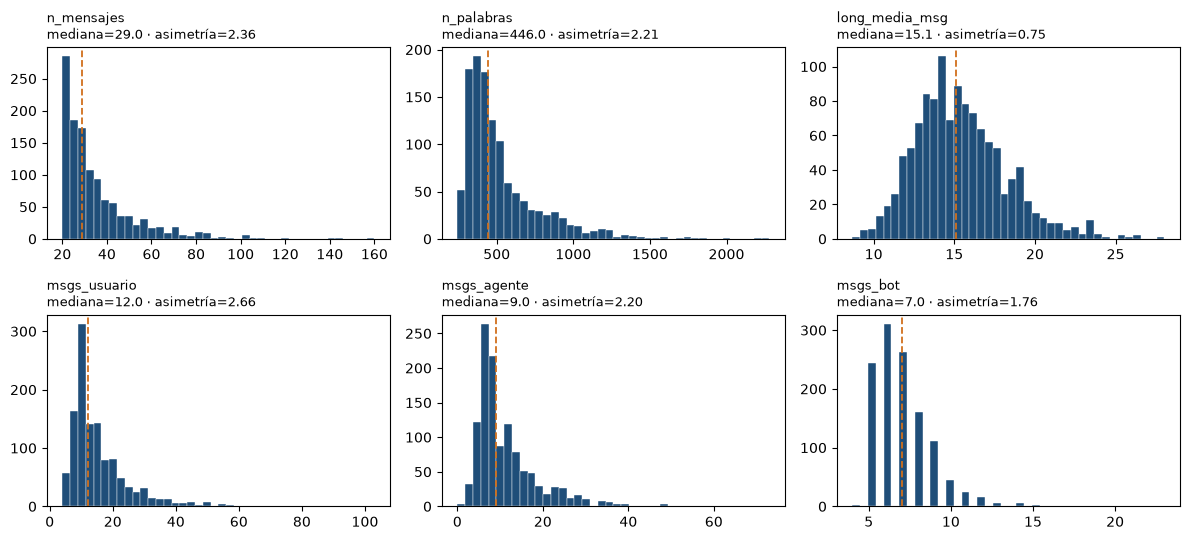

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(12, 5.5))
for a, c in zip(axes.ravel(), numericas[:6]):
    s = conv[c].dropna()
    a.hist(s, bins=40, color='#1f4e79', edgecolor='white', linewidth=0.3)
    a.axvline(s.median(), color='#d1701c', ls='--', lw=1.3)
    a.set_title(f'{c}\nmediana={s.median():.1f} · asimetría={s.skew():.2f}',
                loc='left', fontsize=9)
plt.tight_layout(); plt.show()

In [26]:
# Conversaciones sin participación humana o sin participación del cliente
print('Conversaciones sin ningún mensaje del AGENTE:', (conv.msgs_agente == 0).sum())
print('Conversaciones sin ningún mensaje del USUARIO:', (conv.msgs_usuario == 0).sum())
print('Conversaciones sin mensaje inicial HSM:', (conv.get("msgs_hsm", pd.Series(0, index=conv.index)) == 0).sum())
print()
print('Percentiles de mensajes del agente:')
print(conv.msgs_agente.quantile([.01,.05,.10,.25,.50,.75,.90,.99]).to_string())

Conversaciones sin ningún mensaje del AGENTE: 1
Conversaciones sin ningún mensaje del USUARIO: 0
Conversaciones sin mensaje inicial HSM: 0

Percentiles de mensajes del agente:
0.01     2.00
0.05     4.00
0.10     5.00
0.25     7.00
0.50     9.00
0.75    14.00
0.90    22.00
0.99    39.04


# 5. Analisis Vibariado

## 5.1 Correlacion entr variables derivadas

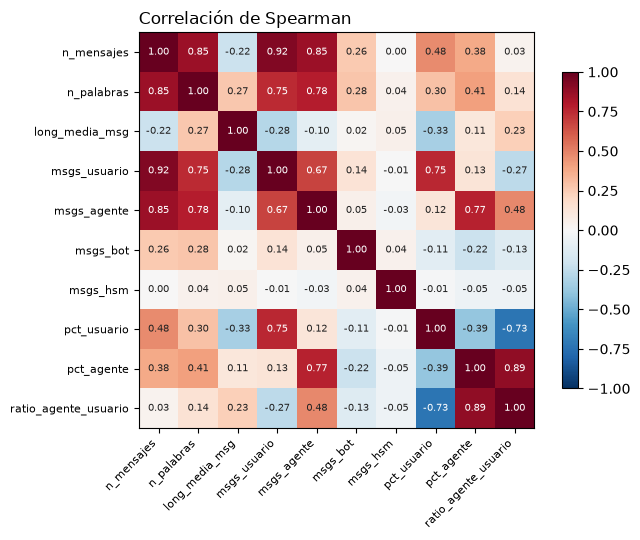

In [27]:
corr = conv[numericas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(numericas))); ax.set_xticklabels(numericas, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(numericas))); ax.set_yticklabels(numericas, fontsize=8)
for i in range(len(numericas)):
    for j in range(len(numericas)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i,j]) > 0.6 else '#222')
ax.set_title('Correlación de Spearman', loc='left')
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

## 5.2 Relacion entre rol y longitud de mensaje

Se utiliza la prueba de Kruskal-Wallis para determinar si existen diferencias significativas en la longitud de los mensajes entre los distintos roles.

In [28]:
from scipy.stats import kruskal

grupos = [g.n_palabras.values for _, g in limpio.groupby('de')]
h, p = kruskal(*grupos)
print(f'Kruskal-Wallis  H = {h:,.1f}   p = {p:.3g}')
print()

limpio.groupby('de').n_palabras.agg(
    n='size', media='mean', mediana='median', p25=lambda s: s.quantile(.25),
    p75=lambda s: s.quantile(.75), maximo='max'
).round(1)

Kruskal-Wallis  H = 22,139.8   p = 0



,n,media,mediana,p25,p75,maximo
de,,,,,,
AGENTE,13770,19.0,14.0,8.0,22.0,256
BOT,8408,25.3,25.0,24.0,29.0,48
HSM,1208,42.2,41.0,37.0,48.0,111
USUARIO,18619,6.0,3.0,1.0,7.0,165


## 5.3 Tabla de contingencia: rol × tramo de longitud

In [29]:
limpio['tramo_long'] = pd.cut(limpio.n_palabras,
                              bins=[-1, 2, 5, 15, 40, np.inf],
                              labels=['1-2', '3-5', '6-15', '16-40', '40+'])

tabla = pd.crosstab(limpio.de, limpio.tramo_long, normalize='index').mul(100).round(1)
print('% de mensajes de cada rol en cada tramo de longitud:')
tabla

% de mensajes de cada rol en cada tramo de longitud:


tramo_long,1-2,3-5,6-15,16-40,40+
de,,,,,
AGENTE,3.2,10.4,42.8,34.7,9.0
BOT,0.0,1.1,6.6,91.6,0.7
HSM,0.0,0.6,2.0,35.8,61.6
USUARIO,41.8,25.0,25.2,7.2,0.9


# 6. EDA de texto

## 6.1 Vocabulario

In [33]:
def tokenizar(serie):
    texto = ' '.join(serie).lower()
    return re.findall(r'[a-záéíóúñü]{3,}', texto)

STOPWORDS = set('''que para con por los las una del una como más pero sus este esta esto
estos estas ese esa eso son fue han hay muy sin sobre entre cuando donde quien cual todo
toda todos todas otro otra otros otras tiene tienen puede pueden debe deben ser está están
haber hacer hace desde hasta ante bajo cabe contra durante mediante según tras'''.split())

tokens = tokenizar(limpio.msg)
frec = Counter(tokens)
frec_sin_sw = Counter({p: c for p, c in frec.items() if p not in STOPWORDS})

print(f'Tokens totales:        {len(tokens):,}')
print(f'Vocabulario (únicos):  {len(frec):,}')
print(f'Riqueza léxica (TTR):  {len(frec)/len(tokens):.4f}')
print(f'Hapax legomena:        {sum(1 for c in frec.values() if c == 1):,} '
      f'({sum(1 for c in frec.values() if c==1)/len(frec)*100:.1f}% del vocabulario)')

Tokens totales:        445,049
Vocabulario (únicos):  8,606
Riqueza léxica (TTR):  0.0193
Hapax legomena:        3,907 (45.4% del vocabulario)


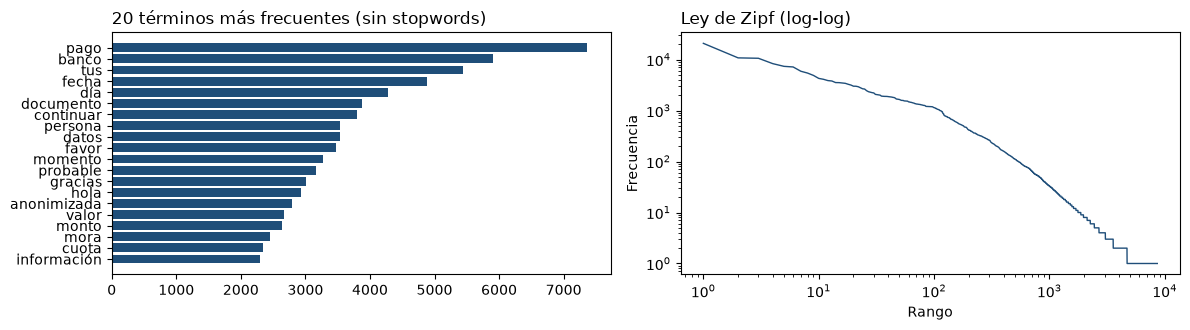

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))

top = frec_sin_sw.most_common(20)[::-1]
ax[0].barh([p for p, _ in top], [c for _, c in top], color='#1f4e79')
ax[0].set_title('20 términos más frecuentes (sin stopwords)', loc='left')

ranks = np.arange(1, len(frec)+1)
freqs = np.array(sorted(frec.values(), reverse=True))
ax[1].loglog(ranks, freqs, color='#1f4e79', lw=1)
ax[1].set_xlabel('Rango'); ax[1].set_ylabel('Frecuencia')
ax[1].set_title('Ley de Zipf (log-log)', loc='left')

plt.tight_layout(); plt.show()

## 6.2 Vocabulario diferencial por Rol

Qué términos son característicos de cada emisor. Es el insumo directo para construir los
diccionarios de la extracción y para entender qué se puede esperar de cada rol.

In [35]:
for rol in ['USUARIO', 'AGENTE', 'BOT']:
    sub = Counter({p: c for p, c in Counter(tokenizar(limpio.loc[limpio.de==rol, 'msg'])).items()
                   if p not in STOPWORDS})
    print(f'--- {rol} ---')
    print(', '.join(f'{p} ({c})' for p, c in sub.most_common(15)))
    print()

--- USUARIO ---
pago (1488), email (1275), documento (1026), gracias (986), anonimizada (906), fecha (860), cuota (716), tengo (688), persona (687), quiero (662), pagar (610), estoy (520), url (486), mes (462), puedo (442)

--- AGENTE ---
pago (3962), valor (2349), monto (2280), día (2148), mora (2123), crédito (1629), persona (1570), documento (1551), fecha (1536), banco (1529), cuota (1508), favor (1407), gracias (1224), tus (1199), credito (1160)

--- BOT ---
continuar (3561), probable (3156), banco (2809), tus (2777), fecha (2492), momento (2457), datos (2392), escala (1672), nos (1652), estamos (1582), favor (1506), asesor (1492), nombre (1357), hola (1352), encuentra (1343)



## 6.3 Bigramas

In [36]:
def bigramas(serie, n=15):
    toks = tokenizar(serie)
    bg = Counter(zip(toks, toks[1:]))
    return [(' '.join(b), c) for b, c in bg.most_common(n)]

for rol in ['USUARIO', 'AGENTE']:
    print(f'--- Bigramas más frecuentes · {rol} ---')
    for b, c in bigramas(limpio.loc[limpio.de==rol, 'msg']):
        print(f'  {b:<32} {c}')
    print()

--- Bigramas más frecuentes · USUARIO ---
  url anonimizada                  485
  fecha anonimizada                421
  jpg url                          356
  image jpg                        352
  por favor                        344
  quiero validar                   285
  validar caso                     282
  anonimizada email                276
  muchas gracias                   268
  medio pago                       267
  deseo contactarme                256
  quiero mas                       187
  mas información                  187
  fecha email                      159
  pago pse                         157

--- Bigramas más frecuentes · AGENTE ---
  por valor                        1405
  por favor                        1404
  valor monto                      1240
  gracias por                      1148
  día hoy                          914
  pago para                        888
  para día                         781
  con mora                         710
  terminado cre

## 6.4 Marcadores de anonimización 

Los datos ya están despersonalizados mediante identificadores como PERSONA_00000109. Estos deben registrarse como marcadores y no interpretarse como nombres o información real por el modelo de extracción.

In [38]:
marcadores = Counter(re.findall(r'\b([A-ZÁÉÍÓÚÑ]+)_(?:\d{6,}|ANONIMIZAD[AO])', ' '.join(limpio.msg)))
pd.DataFrame(marcadores.most_common(), columns=['marcador', 'ocurrencias']).set_index('marcador')

,ocurrencias
marcador,
BANCO,4049
PERSONA,3493
MONTO,2600
FECHA,2453
DOCUMENTO,2017
...,...
USDMONTO,1
SURAMERICPERSONA,1
SRMPERSONA,1


## 6.5 Mensajes Plantilla

Los mensajes que se repiten idénticos en muchas conversaciones son plantillas automáticas.
Identificarlos permite excluirlos del análisis semántico y detectar bucles del bot.

In [39]:
plantillas = (limpio.groupby('msg')
                    .agg(veces=('uk_id_mensaje','size'),
                         conversaciones=('uk_id_conversacion','nunique'),
                         rol=('de', lambda s: s.mode().iloc[0]))
                    .query('conversaciones >= 20')
                    .sort_values('veces', ascending=False))

print(f'Textos que aparecen en 20+ conversaciones: {len(plantillas)}')
print(f'Cubren {plantillas.veces.sum():,} mensajes '
      f'({plantillas.veces.sum()/len(limpio)*100:.1f}% del corpus)')
print()
plantillas.head(12).reset_index().assign(msg=lambda d: d.msg.str[:80])

Textos que aparecen en 20+ conversaciones: 155
Cubren 16,737 mensajes (39.8% del corpus)



,msg,veces,conversaciones,rol
0,ENTENDEMOS QUE EN ESTE MOMENTO NO FUE POSIBLE ...,1179,746,BOT
1,AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEA...,1141,1136,BOT
2,ESTAMOS VALIDANDO TU INFORMACIÓN. EN UN MOMENT...,1129,1123,BOT
3,¡MUCHAS GRACIAS POR TU TIEMPO! SOMOS EL BANCO ...,1033,730,BOT
4,"EN UNA ESCALA DE 0 AL 10, DONDE 0 ES NADA PROB...",758,744,BOT
5,SI,637,418,USUARIO
6,NO HEMOS SABIDO DE TI EN UN TIEMPO ¡ESTAMOS AQ...,452,452,BOT
7,EN UNA ESCALA DEL 0 AL 10 DONDE 0 ES NADA PROB...,399,399,BOT
8,IMAGE@_@JPG@_@URL_ANONIMIZADA,352,215,USUARIO
9,GRACIAS,322,244,USUARIO


In [40]:
# Repetición del mismo texto dentro de una misma conversación (posible bucle)
rep_intra = (limpio.groupby(['uk_id_conversacion','msg']).size()
                   .groupby('uk_id_conversacion').max())

print('Máxima repetición del mismo mensaje dentro de una conversación:')
print(rep_intra.value_counts().sort_index().to_string())
print()
print(f'Conversaciones con un mensaje repetido 3+ veces: {(rep_intra>=3).sum()} '
      f'({(rep_intra>=3).mean()*100:.1f}%)')

Máxima repetición del mismo mensaje dentro de una conversación:
1     284
2     664
3     142
4      55
5      26
6      13
7       8
8       1
10      1
11      1
12      1
15      1

Conversaciones con un mensaje repetido 3+ veces: 249 (20.8%)


# 7. Outliers



In [42]:
def extremos(serie, k=5):
    return pd.concat([serie.nsmallest(k).rename('menores'),
                      serie.nlargest(k).rename('mayores')], axis=1)

print('Conversaciones más cortas y más largas (por nº de mensajes):')
display(extremos(conv.n_mensajes))

print('\nConversaciones con menor y mayor participación del agente:')
display(extremos(conv.msgs_agente))

Conversaciones más cortas y más largas (por nº de mensajes):


,menores,mayores
uk_id_conversacion,,
CONV_00000049,20.0,NaN
CONV_00000069,20.0,NaN
CONV_00000072,20.0,NaN
CONV_00000096,20.0,NaN
CONV_00000119,20.0,NaN
CONV_00000032,NaN,160.0
CONV_00000286,NaN,143.0
CONV_00000296,NaN,143.0
CONV_00000444,NaN,140.0



Conversaciones con menor y mayor participación del agente:


,menores,mayores
uk_id_conversacion,,
CONV_00000353,0.0,NaN
CONV_00000182,1.0,NaN
CONV_00000443,1.0,NaN
CONV_00000802,1.0,NaN
CONV_00000144,2.0,NaN
CONV_00000286,NaN,73.0
CONV_00000444,NaN,55.0
CONV_00000283,NaN,53.0
CONV_00000129,NaN,49.0


In [43]:
def mostrar_conversacion(cid, max_car=150):
    print('=' * 20, cid, '=' * 20)
    for _, r in limpio[limpio.uk_id_conversacion == cid].sort_values('orden').iterrows():
        print(f"[{r['de'][:7]:7s}] {r['msg'][:max_car]}")

mostrar_conversacion(conv.n_mensajes.idxmax())

==================== CONV_00000032 ====================
[HSM    ] BANCO_000001 :BLUE_HEART: ¡HOLA! HEMOS INTENTADO COMUNICARNOS CONTIGO POR DIFERENTES CPERSONA_00000008LES SIN ÉXITO. QUEREMOS ESCUCHARTE Y BRINDARTE A
[USUARIO] ME INTERESA
[BOT    ] AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA LEY 1581 DEL FECHA_00000213 DE PROTECCIÓN DE DATOS QUE SE ENCUENTRA EN EL SIGUI
[BOT    ] ESTAMOS VALIDANDO TU INFORMACIÓN. EN UN MOMENTO, UNO DE NUESTROS ASESORES TE AYUDARÁ A ENCONTRAR LA MEJOR ALTERNATIVA PARA QUE ESTÉS AL DÍA CON TUS OB
[BOT    ] HOLA, MI NOMBRE ES PERSONA_00000006, SOY ASESOR DEL BANCO_000001. POR FAVOR INDÍCAME LA FECHA DE EXPEDICIÓN DE TÚ DOCUMENTO Y EL CORREO ELECTRÓNICO RE
[USUARIO] REALIZAR PAGO
[USUARIO] ALISSON BUENAS TARDES
[USUARIO] TENGO MORA EN ALGUNAS OBLIGACIONES
[USUARIO] QUIERO SABER EN CUÁLES Y LOS DÍAS DE MORA
[USUARIO] ESPERO PAGARLAS AL 10 DE PERSONA_00000108
[AGENTE ] POR FAVOR INDÍCAME LA FECHA DE EXPEDICIÓN DE TÚ DOCUMENTO Y EL 

# 8. Resumen de Calidad

In [44]:
decisiones = pd.DataFrame([
    ('Filas duplicadas exactas',      f'{dup_completas:,}',            'Eliminar'),
    ('uk_id_mensaje repetido',        f'{dup_id_msg:,}',               'Se resuelve al eliminar duplicados'),
    ('uk_id_conversacion1',           'Copia exacta de la llave',      'Descartar columna'),
    ('anio',                          f'Constante ({df.anio.iloc[0]})','Descartar: sin poder discriminante'),
    ('mes',                           f'Constante ({df.mes.iloc[0]})', 'Descartar: no hay eje temporal'),
    ('mensaje nulo',                  f'{df.mensaje.isna().sum()}',    'Imputar a cadena vacía'),
    ('total_interacciones',           'Difiere del conteo real',       'Recalcular desde los datos'),
    ('Sin timestamp',                 'No existe la columna',          'Usar consecutivo de uk_id_mensaje'),
    ('Mínimo de 20 mensajes/conv.',   'Corpus truncado por diseño',    'Declarar como limitación'),
], columns=['Hallazgo', 'Magnitud', 'Decisión'])

decisiones

,Hallazgo,Magnitud,Decisión
0,Filas duplicadas exactas,602,Eliminar
1,uk_id_mensaje repetido,602,Se resuelve al eliminar duplicados
2,uk_id_conversacion1,Copia exacta de la llave,Descartar columna
3,anio,Constante (2010),Descartar: sin poder discriminante
4,mes,Constante (Julio),Descartar: no hay eje temporal
5,mensaje nulo,1,Imputar a cadena vacía
6,total_interacciones,Difiere del conteo real,Recalcular desde los datos
7,Sin timestamp,No existe la columna,Usar consecutivo de uk_id_mensaje
8,Mínimo de 20 mensajes/conv.,Corpus truncado por diseño,Declarar como limitación


In [45]:
import os
os.makedirs('../outputs', exist_ok=True)

limpio.drop(columns=['tramo_long']).to_csv('../outputs/mensajes_limpios.csv', index=False)
conv.to_csv('../outputs/conversaciones.csv')
perfil.to_csv('../outputs/perfil_columnas.csv')

print('Guardado:')
print('  ../outputs/mensajes_limpios.csv   — nivel mensaje, limpio y ordenado')
print('  ../outputs/conversaciones.csv     — nivel conversación, tabla agregada')
print('  ../outputs/perfil_columnas.csv    — perfil de calidad de columnas')

Guardado:
  ../outputs/mensajes_limpios.csv   — nivel mensaje, limpio y ordenado
  ../outputs/conversaciones.csv     — nivel conversación, tabla agregada
  ../outputs/perfil_columnas.csv    — perfil de calidad de columnas
